# <a id='toc1_'></a>[C61](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [C61](#toc1_)    
  - [📆 data as of](#toc1_1_)    
  - [C61 gleason](#toc1_2_)    
  - [C50](#toc1_3_)    
  - [D35.2](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import os
from pathlib import Path
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp

hlp.show_package_version(["pygwalker"])
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'

if not file_db_clin.exists():
    raise(FileNotFoundError(f"File {file_db_clin} not found"))

🐍 3.12.8 | 📦 pygwalker: 0.4.9.15 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.21.2 | 📦 connection-helper: 0.13.1


In [2]:
con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

## <a id='toc1_1_'></a>[📆 data as of](#toc0_)

In [3]:
sql.print_meta(file_db_clin)

sqlite db file:          2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2025-11-11 16:09:19


In [4]:
# print(con.sql("""select * from Tumor""").columns)

## <a id='toc1_2_'></a>[C61 gleason](#toc0_)

In [5]:
t_gleas = con.sql("""--sql
    select  z_icd10,
            z_kkr_label,
            z_sex,
            ScoreErgebnis,
            GradPrimaer,
            GradSekundaer,
            AnlassGleasonScore,
    from Tumor
    where z_icd10_3d = 'C61'
    and z_sex = 'M'
    and z_dy between 2021 and 2023
    """)
tbl.descr_db(t_gleas,"gleason")

🗄️ gleason	226_994, 7
	("z_icd10, z_kkr_label, z_sex, ScoreErgebnis, GradPrimaer, GradSekundaer, AnlassGleasonScore")
┌─────────┬─────────────┬─────────┬───────────────┬─────────────┬───────────────┬────────────────────┐
│ z_icd10 │ z_kkr_label │  z_sex  │ ScoreErgebnis │ GradPrimaer │ GradSekundaer │ AnlassGleasonScore │
│ varchar │   varchar   │ varchar │    varchar    │   varchar   │    varchar    │      varchar       │
├─────────┼─────────────┼─────────┼───────────────┼─────────────┼───────────────┼────────────────────┤
│ C61     │ 07-RP       │ M       │ NULL          │ NULL        │ NULL          │ NULL               │
│ C61     │ 05-NW       │ M       │ NULL          │ NULL        │ NULL          │ NULL               │
│ C61     │ 05-NW       │ M       │ NULL          │ NULL        │ NULL          │ NULL               │
└─────────┴─────────────┴─────────┴───────────────┴─────────────┴───────────────┴────────────────────┘



In [6]:
df = t_gleas.project("ScoreErgebnis").to_df()
pls.plot_bars(df, sort_values=True, caption="C61")

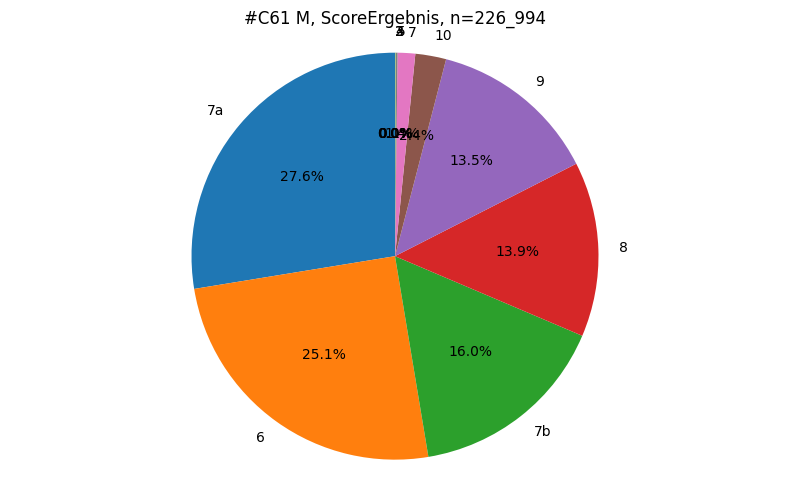

In [7]:
df = t_gleas.project("ScoreErgebnis").to_df()
pls.plot_pie(df, caption="C61 M")

In [8]:
# con.sql("""--sql
# select case 
#             when ScoreErgebnis in ('2', '3', '4', '5') then '2-5'
#             when ScoreErgebnis is null then '<NA>'
#             else ScoreErgebnis end as ScoreErgebnis
# from t_gleas
# """).aggregate("ScoreErgebnis, count(*) as Anzahl").order("Anzahl desc").to_df().to_excel("2025-09-19.xlsx", index=False)

In [9]:
df = t_gleas.project("z_kkr_label, lpad(ScoreErgebnis, 2, '0') as ScoreErgebnis").to_df()
pls.plot_stacked_bars(df, orientation='h', relative=True, show_total=True, height=600)

In [10]:
df = t_gleas.project("GradPrimaer").to_df()
pls.plot_bars(df, sort_values=True, caption="C61", height=300)

In [11]:
df = t_gleas.project("AnlassGleasonScore").to_df()
pls.plot_bars(df, sort_values=True, caption="C61", height=300)